In [1]:

import pandas as pd
import json
import os
#curent directory is notebooks, change to project root
#print current directory
print(f"Current directory: {os.getcwd()}")

Current directory: /home/vlad/project/bench


In [2]:

dir_result="out/pubmed-conclusion/"
#change current directory to dir_result and load scores
os.chdir(dir_result)


In [3]:
#list folders
folders = [f for f in os.listdir() if os.path.isdir(f)]
print(f"folders: {folders}")

folders: ['20260411_2030', '20260412_1711', '20260412_1633', '20260411_1601', '20260412_1800', '20260411_1646']


In [4]:
from pathlib import Path

# 1. Define your folders

all_rows = []

# 2. Iterate through folders and files
for folder_name in folders:
    # Use glob to find all json files in the folder
    pathlist = [path for path in Path(folder_name).glob('scores.json') ]
    
    for path in pathlist:
        file_name = path.name
        with open(path, 'r') as f:
            data = json.load(f)
            
            # 3. Flatten the specific hierarchy: {record_id: {k1: {k2: value}}}
            for record_id, level1_dict in data.items():
                for k1, level2_dict in level1_dict.items():
                    # Check if the next level is indeed a dict (prevents errors on unexpected formats)
                    if isinstance(level2_dict, dict):
                        for k2, value in level2_dict.items():
                            all_rows.append({
                                'folder':folder_name,
                                'file': file_name,
                                'record_id': record_id,
                                'metric': k1,
                                'judge': k2,
                                'value': value
                            })
                    else:
                        # Handle cases where there might not be a level 2
                        all_rows.append({
                            'file': file_name,
                            'record_id': record_id,
                            'metric': k1,
                            'judge': None,
                            'value': level2_dict
                        })

# 4. Create the DataFrame
df = pd.DataFrame(all_rows)

# Optional: Filter for specific keys if you only want 'quality'
# df = df[df['metric'] == 'quality']

print(df.head())

# 5. Export for comparison
#df.to_csv("model_comparison_master.csv", index=False)

          folder         file            record_id     metric  \
0  20260411_2030  scores.json  10.1167/iovs.67.2.1    quality   
1  20260411_2030  scores.json  10.1167/iovs.67.2.1    quality   
2  20260411_2030  scores.json  10.1167/iovs.67.2.1    quality   
3  20260411_2030  scores.json  10.1167/iovs.67.2.1  grounding   
4  20260411_2030  scores.json  10.1167/iovs.67.2.1  grounding   

                               judge  value  
0     openai/gpt-5.4-nano-2026-03-17    0.5  
1  anthropic/claude-opus-4-6@default    0.0  
2      google/gemini-3.1-pro-preview    0.5  
3     openai/gpt-5.4-nano-2026-03-17    1.0  
4  anthropic/claude-opus-4-6@default    1.0  


In [5]:
#pivot df with folder,record_id as idx and metric_judge as columns
scores = (df.assign(new_col_name=lambda x: x['metric'].astype(str) + ':' + x['judge'].astype(str))
    .pivot_table(index=['record_id'], columns='new_col_name', values='value', aggfunc='mean') # Pivot the DataFrame
    .reset_index()          # Flattens the multi-index created by pivot
    .rename_axis(None, axis=1) # Removes the 'new_col_name' label over the columns
)


In [6]:
vars = scores.columns.tolist()[1:]
print(f"vars: {vars}")

vars: ['grounding:anthropic/claude-opus-4-6@default', 'grounding:google/gemini-3.1-pro-preview', 'grounding:openai/gpt-5.4-nano-2026-03-17', 'quality:anthropic/claude-opus-4-6@default', 'quality:google/gemini-3.1-pro-preview', 'quality:openai/gpt-5.4-nano-2026-03-17']


In [7]:
ds_name='pubmed'
file_csv = f"{ds_name}.csv"
file_path = f"../result_conclusion/{ds_name}/{file_csv}"
ds=pd.read_csv(file_path)







In [8]:
df = scores.merge(ds, left_on='record_id' , right_on='doi', how='inner')
df.head(5)

,record_id,grounding:anthropic/claude-opus-4-6@default,grounding:google/gemini-3.1-pro-preview,grounding:openai/gpt-5.4-nano-2026-03-17,quality:anthropic/claude-opus-4-6@default,quality:google/gemini-3.1-pro-preview,quality:openai/gpt-5.4-nano-2026-03-17,pmid,doi,pt,mesh,aim,method,result,conclusion,abstract
0,10.1002/ejp.70226,0.900000,0.846667,0.890000,0.600,0.800,0.60,41627937,10.1002/ejp.70226,Journal Article,"Humans; *Analgesics, Opioid/therapeutic use; M...",BACKGROUND: Continuity of care is a core eleme...,We conducted a population-based cohort study u...,"Among 392,988 participants, 52,670 (13.4%) ini...",Higher continuity of primary care was associat...,BACKGROUND: Continuity of care is a core eleme...
1,10.1007/s00203-026-04725-9,0.437500,0.862500,0.625000,0.750,0.750,0.00,41627476,10.1007/s00203-026-04725-9,Journal Article,Animals; *Gastrointestinal Microbiome/drug eff...,NaN,NaN,Yeast is a core microorganism long used in foo...,MTE represents a dietary supplement with immun...,Yeast is a core microorganism long used in foo...
2,10.1007/s00405-025-09980-y,0.791667,0.822917,0.833333,0.375,0.250,0.50,41622272,10.1007/s00405-025-09980-y,Comparative Study; Journal Article,Humans; *Pulmonary Embolism/prevention & contr...,BACKGROUND: Total laryngectomy is a common pro...,This single-center retrospective study include...,"In our cohort, 13 patients (13%) developed pul...",IPCS significantly reduced PE risk compared to...,BACKGROUND: Total laryngectomy is a common pro...
3,10.1007/s00520-026-10323-8,0.908333,0.982143,0.895833,0.500,0.750,0.50,41627499,10.1007/s00520-026-10323-8,Journal Article; Review; Systematic Review,Humans; *Hyperbaric Oxygenation/methods; *Neop...,BACKGROUND: Radiotherapy (RT) is a cornerstone...,"A systematic review of PubMed, Embase, and Coc...",Forty-two studies (2785 patients) were include...,HBOT shows promising activity in mitigating la...,BACKGROUND: Radiotherapy (RT) is a cornerstone...
4,10.1007/s00701-026-06784-9,0.625000,0.677083,0.791667,0.375,0.375,0.25,41629728,10.1007/s00701-026-06784-9,Journal Article; Review; Systematic Review,Humans; *Algorithms; *Postoperative Complicati...,PURPOSE: Unilateral biportal endoscopy (UBE) h...,"A PRISMA-aligned search of PubMed, Scopus, Web...",Eighteen studies met inclusion criteria: eight...,Lumbar UBE decompression appears safe and repr...,PURPOSE: Unilateral biportal endoscopy (UBE) h...


Detected Features (including multi-word names):
['comparative study' 'english abstract' 'journal article' 'meta-analysis'
 'multicenter study' 'observational study' 'randomized controlled trial'
 "research support, non-u.s. gov't" 'review' 'systematic review']
Coefficient Matrix (Predictive Power of each string):
                                             comparative study  \
grounding:anthropic/claude-opus-4-6@default           0.060424   
grounding:google/gemini-3.1-pro-preview               0.034634   
grounding:openai/gpt-5.4-nano-2026-03-17              0.038403   
quality:anthropic/claude-opus-4-6@default             0.014411   
quality:google/gemini-3.1-pro-preview                -0.047404   
quality:openai/gpt-5.4-nano-2026-03-17                0.088327   

                                             english abstract  \
grounding:anthropic/claude-opus-4-6@default          0.013409   
grounding:google/gemini-3.1-pro-preview             -0.022743   
grounding:openai/gpt-5.4-na

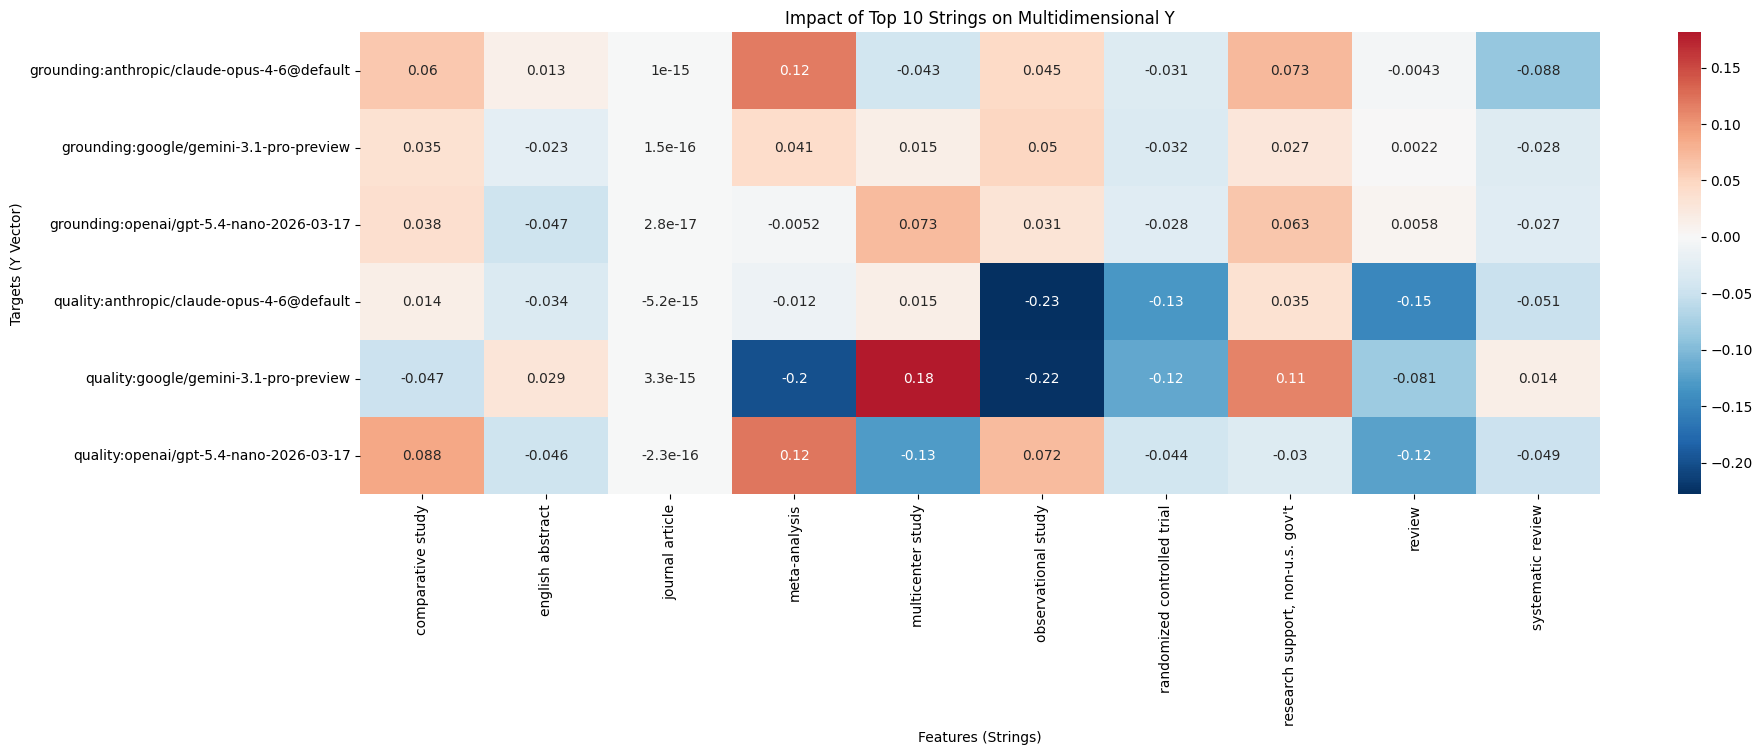

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# 1. Setup Mock Data
# X is a list of strings (e.g., tags, categories)
# Y is a multidimensional numeric array
#first 4 columns are Y targets, the last column is the text feature
Y = df[vars].values
Y=np.where(np.isnan(Y), np.nanmean(Y, axis=0), Y)
def semicolon_tokenizer(text):
    return [tag.strip() for tag in text.split(';') if tag.strip()]
vectorizer = CountVectorizer(tokenizer=semicolon_tokenizer, 
    token_pattern=None, 
    binary=True, 
    max_features=20)
X = vectorizer.fit_transform(df['pt'])
# Check the features
print("Detected Features (including multi-word names):")
print(vectorizer.get_feature_names_out())
feature_names = vectorizer.get_feature_names_out()

# 3. Fit the Multi-Output Model
# Ridge regression is highly interpretable via coefficients
model = MultiOutputRegressor(Ridge(alpha=1.0))
model.fit(X, Y)

# 4. Extract Interpretability (Coefficients)
# coefficients shape: (n_targets, n_features)
coefficients = np.array([est.coef_ for est in model.estimators_])

coef_df = pd.DataFrame(
    coefficients, 
    columns=feature_names, 
    index=vars
)

print("Coefficient Matrix (Predictive Power of each string):")
print(coef_df)

# 5. Visualize the relationships
plt.figure(figsize=(20, 6))
sns.heatmap(coef_df, annot=True, cmap='RdBu_r', center=0)
plt.title("Impact of Top 10 Strings on Multidimensional Y")
plt.xlabel("Features (Strings)")
plt.ylabel("Targets (Y Vector)")
plt.show()

In [16]:
df[df['pt'].str.contains('observational study',case=False, na=False)].shape[0]

3

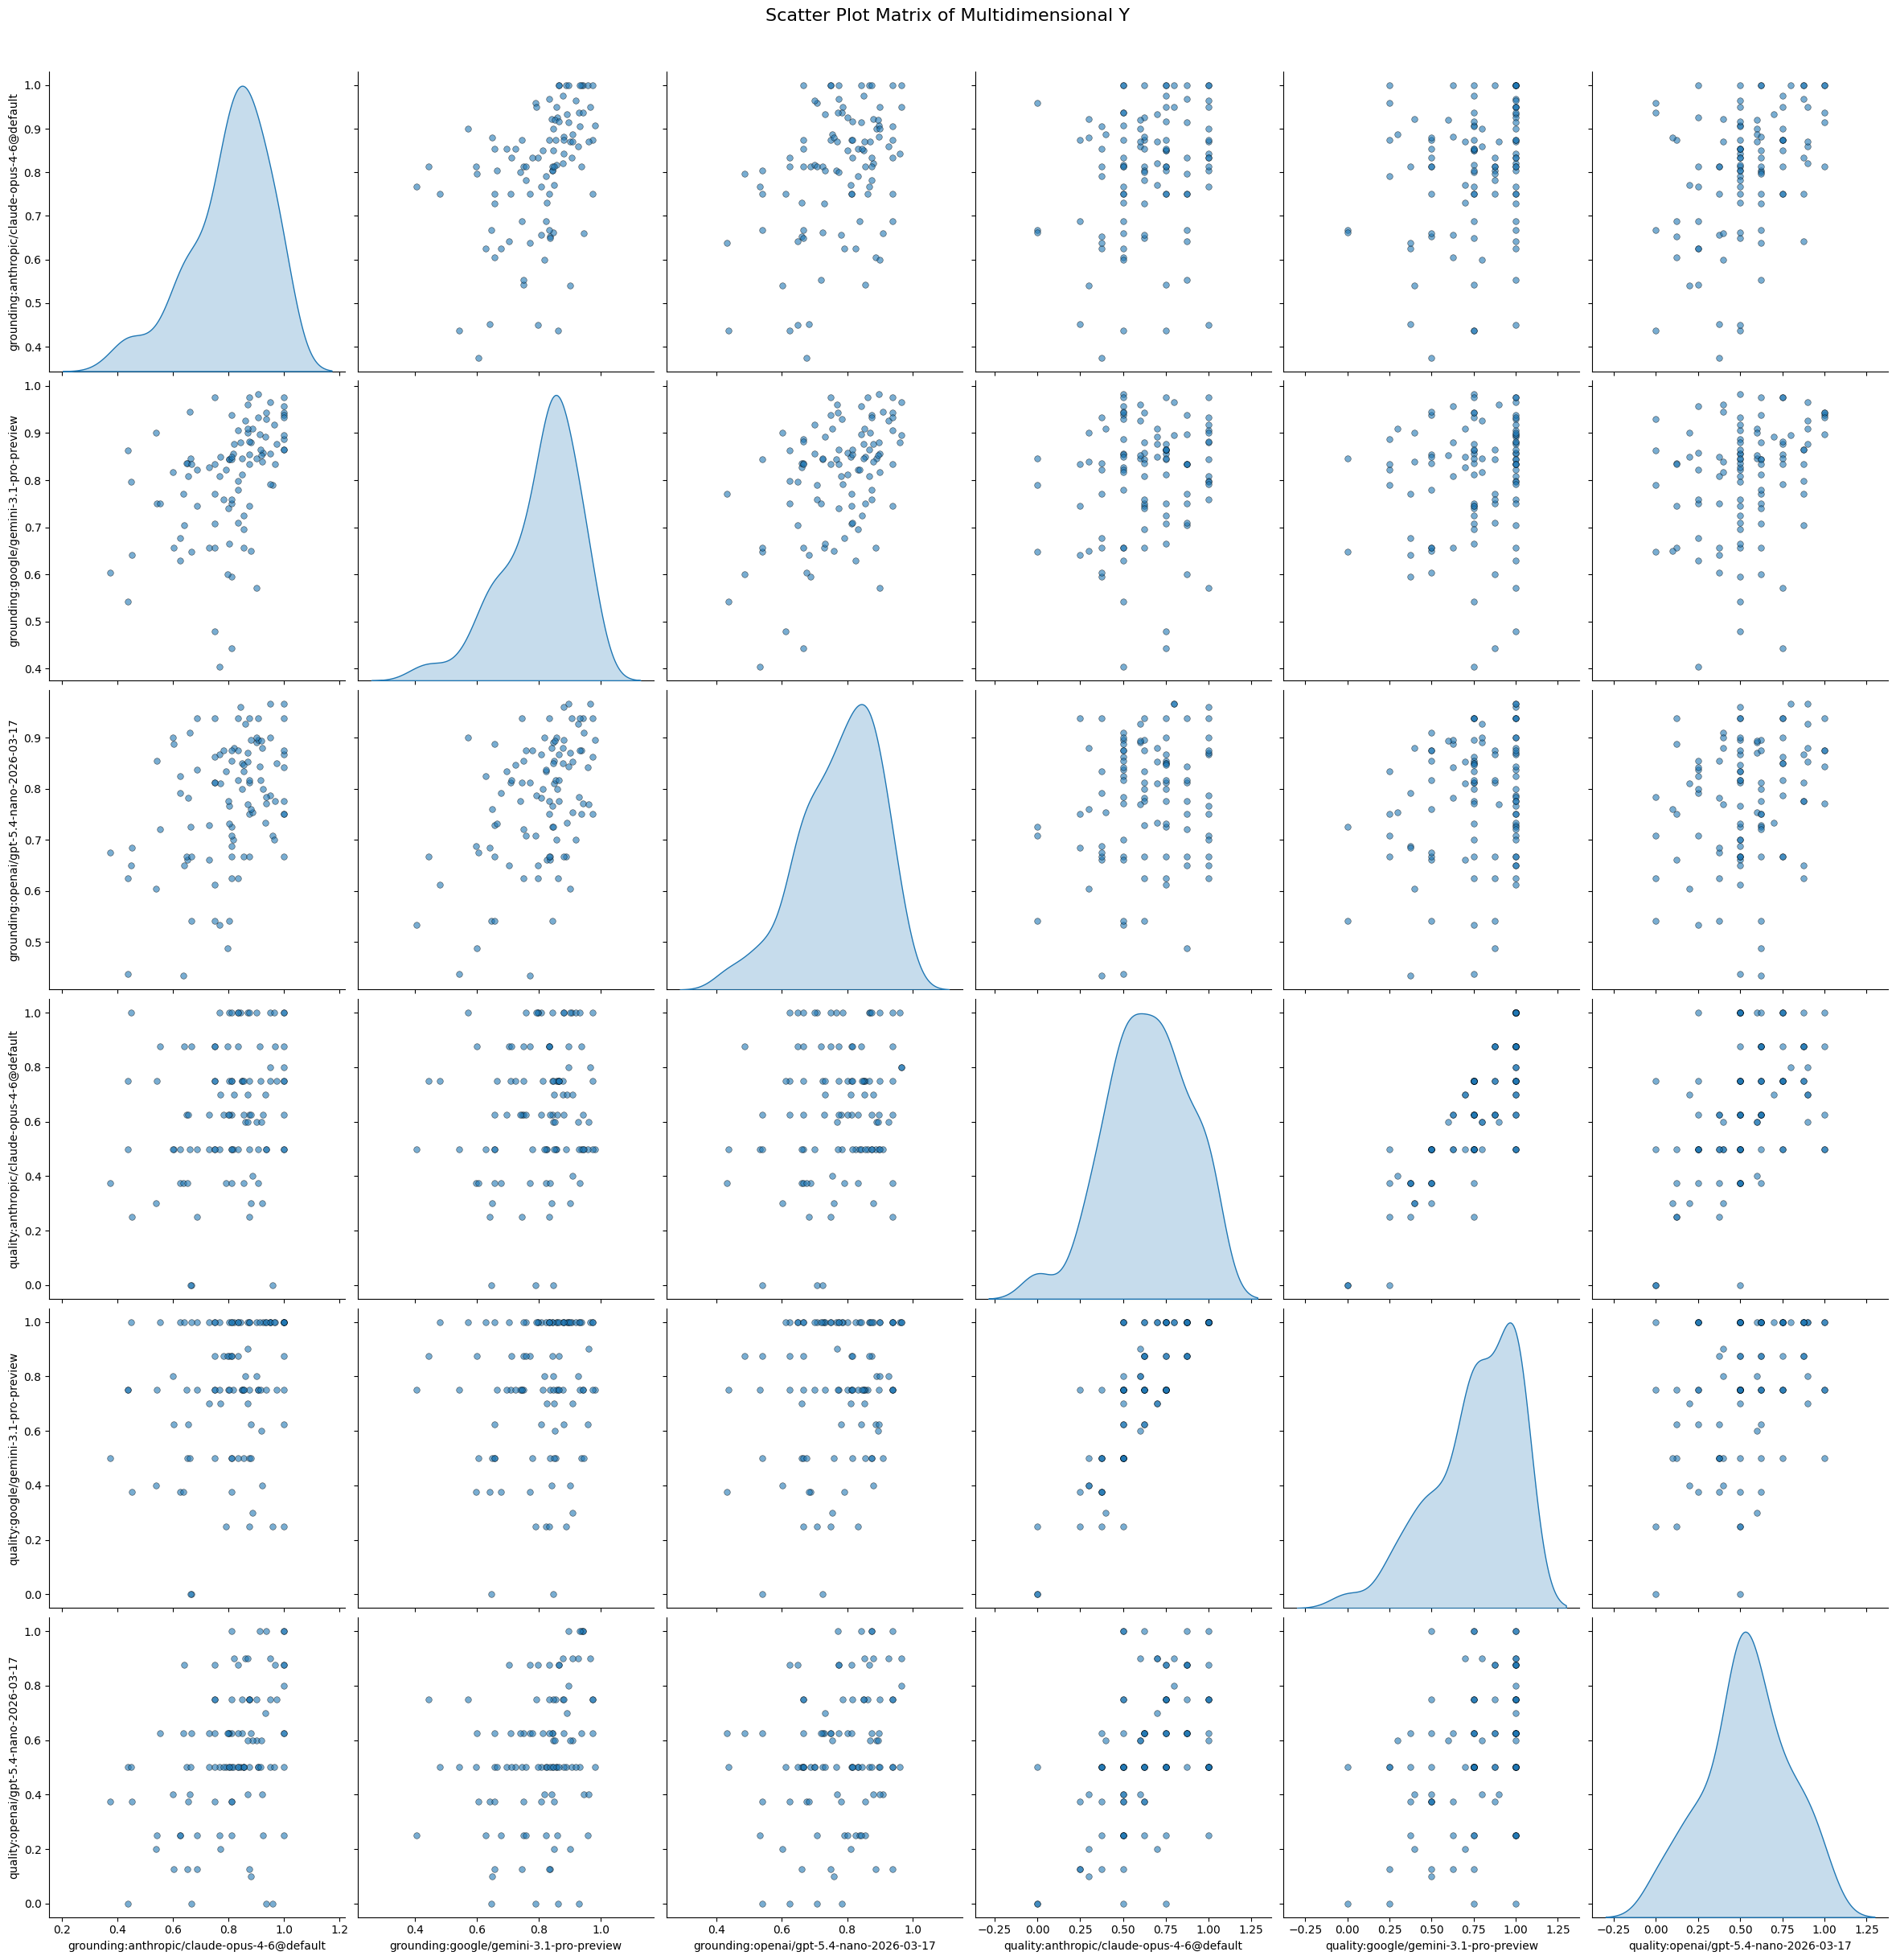

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert your Y matrix to a DataFrame for labeled plotting
# Assuming Y is a numpy array
target_names = list(df.columns[:scores.shape[1]])
df_y = pd.DataFrame(Y, columns=vars)

# 2. Create the Scatter Plot Matrix
# diag_kind='kde' puts density plots on the diagonal instead of histograms
# plot_kws={'alpha': 0.5} makes points semi-transparent to see density
g = sns.pairplot(
    df_y, 
    diag_kind='kde', 
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'},
    height=4
)

# 3. Add a title
g.fig.suptitle('Scatter Plot Matrix of Multidimensional Y', y=1.02, fontsize=16)

plt.show()